# Inclusion of eML_tranistion and unclassified to classification column from original predictions

In [1]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed.h5ad")

In [17]:
adata

AnnData object with n_obs × n_vars = 82408 × 4000
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_scVI', 'X_totalvi_scarches', 'X_umap', 'protein_expression'
    layers: 'cou

In [18]:
adata.obs["predictionsBBC"].value_counts()

predictionsBBC
CD56dim       66596
ML1            6940
CD56bright     5441
ML2            3431
Name: count, dtype: int64

In [19]:
#Ml transition and unclassified
#argmax error
# Define the column names for probabilities and their corresponding labels
probability_columns = ['CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob']
labels = ['CD56bright', 'CD56dim', 'ML1', 'ML2']

# Ensure the probability columns are numeric
for col in probability_columns:
    adata.obs[col] = pd.to_numeric(adata.obs[col], errors='coerce')  # Convert to numeric, set errors as NaN

# Function to classify rows based on conditions
def classify_row(row):
    # Check if all probabilities are less than 0.5
    if all(row[col] < 0.5 for col in probability_columns):
        # If combined probability of 'eML1BBCprob' and 'eML2BBCprob' is greater than 0.5, classify as ML_transition
        if row['eML1BBCprob'] + row['eML2BBCprob'] > 0.5:
            return 'ML_transition'
        else:
            return 'unclassified'
    else:
        # Find the column with the maximum probability
        max_index = row[probability_columns].astype(float).idxmax()  # Ensure values are treated as numeric
        return labels[probability_columns.index(max_index)]  # Return the corresponding label

# Apply the classification function to each row in `adata.obs`
adata.obs['classification'] = adata.obs.apply(classify_row, axis=1)

# View the first few rows to verify the classification
print(adata.obs[['CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'classification']].head())

                      CD56brightBBCprob  CD56dimBBCprob  eML1BBCprob  \
AAACCTGAGTGTCCAT_1-0           0.000015        0.916029     0.002898   
AAACCTGCACATGGGA_1-0           0.006781        0.449843     0.513039   
AAACCTGCACCTCGGA_1-0           0.001876        0.819067     0.153348   
AAACCTGGTTGAGTTC_1-0           0.002462        0.233508     0.660819   
AAACCTGTCACCGTAA_1-0           0.000141        0.743346     0.241678   

                      eML2BBCprob classification  
AAACCTGAGTGTCCAT_1-0     0.081058        CD56dim  
AAACCTGCACATGGGA_1-0     0.030338            ML1  
AAACCTGCACCTCGGA_1-0     0.025708        CD56dim  
AAACCTGGTTGAGTTC_1-0     0.103212            ML1  
AAACCTGTCACCGTAA_1-0     0.014836        CD56dim  


In [7]:
adata.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

In [9]:
#adata.write_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification.h5ad")

In [10]:
#adata.obs.to_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification.csv")

In [23]:
adata

AnnData object with n_obs × n_vars = 82408 × 4000
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_scVI', 'X_totalvi_scarches', 'X_umap', 'protein_expression

In [24]:
adata.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

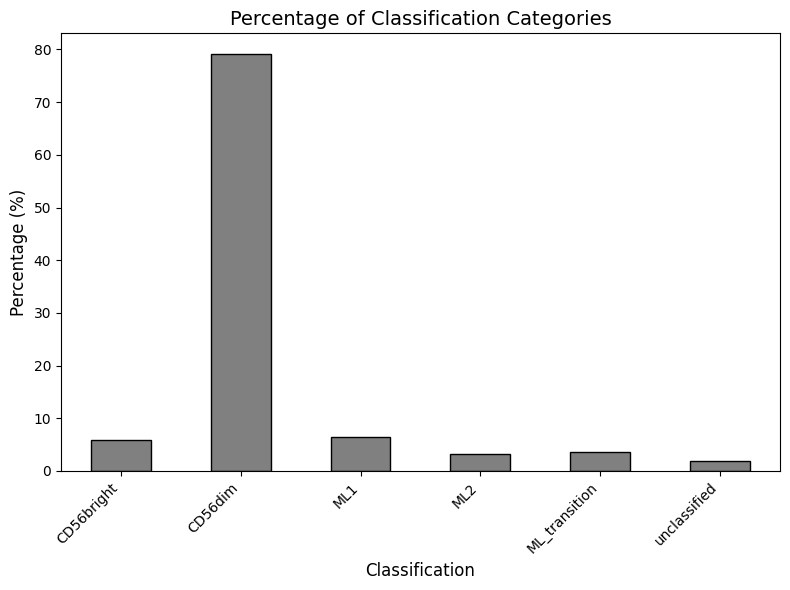

In [26]:

# Define the desired order for classification categories
desired_order = ['CD56bright', 'CD56dim', 'ML1', 'ML2', 'ML_transition', 'unclassified']

# Calculate the percentage of each classification category
classification_counts = adata.obs['classification'].value_counts(normalize=True) * 100

# Reorder classification_counts based on the desired order
classification_counts = classification_counts[desired_order]

# Plot the percentages with the desired order
plt.figure(figsize=(8, 6))
classification_counts.plot(kind='bar', color='grey', edgecolor='black')
plt.title('Percentage of Classification Categories', fontsize=14)
plt.xlabel('Classification', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
# Group by 'source' and count unique 'patient_ID_v2's
patient_counts_by_source = adata.obs.groupby("source")["patient_ID_v2"].nunique()

# Print the results
print("Number of unique patients per source:")
print(patient_counts_by_source)

Number of unique patients per source:
source
PBMC               12
breast_normal       6
breast_tumor       83
glioblastoma       98
lung_normal        66
lung_tumor         93
melanoma            8
pancreas_normal     9
pancreas_tumor     40
prostate_normal    10
prostate_tumor     23
sarcoma            18
skin_normal        23
Name: patient_ID_v2, dtype: int64


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_98271/2729898144.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts_by_source = adata.obs.groupby("source")["patient_ID_v2"].nunique()
